# Analysis of the D3FEND Side + Playbooks

## Setup

In [3]:
techniques_list = {
    'Model': ['ConfigurationInventory','AccessModeling','OrganizationMapping','AssetVulnerabilityEnumeration','DataInventory',
              'NetworkNodeInventory','SystemVulnerabilityAssessment','OperationalRiskAssessment','DataExchangeMapping', 'SystemDependencyMapping',
              'SoftwareInventory', 'OperationalDependencyMapping','ServiceDependencyMapping','NetworkTrafficPolicyMapping', 'HardwareComponentInventory','LogicalLinkMapping',
               'PhysicalLinkMapping'
              ],
    'Harden': ['CredentialRotation','UserAccountPermissions','MessageAuthentication','MessageEncryption','SoftwareUpdate','SystemConfigurationPermissions',
               'DomainTrustPolicy','StrongPasswordPolicy','CredentialTransmissionScoping','ApplicationConfigurationHardening','DeadCodeElimination','ExceptionHandlerPointerValidation',
                'PointerAuthentication','ProcessSegmentExecutionPrevention','SegmentAddressOffsetRandomization','StackFrameCanaryValidation','BiometricAuthentication','Certificate-basedAuthentication',
                'CertificatePinning','Multi-factorAuthentication','One-timePassword','TransferAgenAuthentication','BootloaderAuthentication','DiskEncryption','DriverLoadIntegrityChecking','FileEncryption',
                'LocalFilePermissions','RFShielding','TPMBootIntegrity'
               ],
    'Detect': ['IdentifierReputationAnalysis','DynamicAnalysis','SenderReputationAnalysis','URLAnalysis', 'LocalAccountMonitoring',
               'UserGeolocationLogonPatternAnalysis','OperatingSystemMonitoring','FileHashing', 'IdentifierActivityAnalysis', 'AuthenticationEventThresholding',
               'AuthorizationEventThresholding', 'ResourceAccessPatternAnalysis','AdministrativeNetworkActivityAnalysis','FileIntegrityMonitoring',
               'DatabaseQueryStringAnalysis','SenderMTAReputationAnalysis','ConnectionAttemptAnalysis','InboundSessionVolumeAnalysis', 'FirmwareBehaviorAnalysis',
               'ProtocolMetadataAnomalyDetection','FirmwareVerification','ProcessSpawnAnalysis','SystemCallAnalysis','ScriptExecutionAnalysis',
               'RemoteTerminalSessionDetection','DNSTrafficAnalysis','FileAccessPatternAnalysis','DomainAccountMonitoring','ProcessCodeSegmentVerification',
                'ShadowStackComparisons','Client-serverPayloadProfiling','NetworkTrafficCommunityDeviation','CredentialCompromiseScopeAnalysis','RPCTrafficAnalysis',
                'JobFunctionAccessPatternAnalysis','FileContentAnalysis','CertificateAnalysis','NetworkTrafficSignatureAnalysis','RelayPatternAnalysis','FirmwareEmbeddedMonitoringCode',
                'EmulatedFileAnalysis','HomoglyphDetection','ByteSequenceEmulation','FileCarving','IPCTrafficAnalysis','PerHostDownload-UploadRatioAnalysis',
                'IndirectBranchCallAnalysis','ProcessSelf-ModificationDetection','SessionDurationAnalysis','UserDataTransferAnalysis','WebSessionActivityAnalysis'
               ],
    'Isolate': ['Hardware-basedProcessIsolation','IOPortRestriction','Kernel-basedProcessIsolation','NetworkTrafficFiltering','ExecutableDenylisting','BroadcastDomainIsolation','ExecutableAllowlisting','DNSDenylisting','DNSAllowlisting','EncryptedTunnels'],
    'Deceive': ['ConnectedHoneynet','IntegratedHoneynet','StandaloneHoneynet','DecoyFile','DecoyNetworkResource','DecoyPersona','DecoyPublicRelease','DecoySessionToken','DecoyUserCredential'],
    'Evict': ['AccountLocking','FileRemoval','ProcessTermination','HostShutdown','CredentialRevoking','AuthenticationCacheInvalidation','ProcessSuspension',],
    'Restore': ['ReissueCredential','RestoreNetworkAccess','RestoreFile','RestoreUserAccountAccess','RestoreDiskImage','RestoreConfiguration','RestoreDatabase','RestoreSoftware']
    }

In [107]:
import pandas as pd
import math
import ast
import matplotlib.pyplot as plt
import numpy as np

df_art = pd.read_csv('artifacts_D3fend_mapped.csv', delimiter=';')
df_def = pd.read_csv('mapping.csv', header=None)
df_def.columns = ['playbook_id','techniques']
df_playbooks = pd.read_csv('playbooks.csv')

df_art.head()
#df_def.head()

vendor_df = df_playbooks[['id','vendor', 'tags', 'steps']]
df_reload = pd.read_csv('mapping.csv', header=None, names=['id','mapping'])
#print(vendor_df.head())

combined_df = pd.merge(df_art, df_def, on='playbook_id')
combined_df.head()
df_def['techniques_clean'] = None
df_def['techniques_count'] = None
df_def['steps'] = 1
df_def['ratio_t_s'] = None
df_def['artifacts'] = None
df_def['artifacts_count'] = None
df_def['tactics'] = None
df_def['tactics_count'] = None
df_def['ratio_a_s'] = None

# Infos die ich brauche:
# - Anzahl an Steps für jedes Playbook
# - Anzahl and Artifacts für jedes Playbook
# - Anzahl an Techniques pro Playbook
# - Anzahl an Tactics pro Playbooks
# - Verhältnis von Schritten zu artifacts


for index, value in df_def.iterrows():
    id = value['playbook_id']
    artifacts_df = df_art[df_art['playbook_id'] == id]
    steps = 0
    artifacts_pb = []
    for index_a, value_a in artifacts_df.iterrows():
        steps += 1
        artifacts_pb.append(value_a['artifact'])
    # add new columns to df_df
    cleaned_list = [x for x in artifacts_pb if isinstance(x, str) and pd.notna(x)]

    if steps == 0:
        #print(id)
        new_playbook_data = df_playbooks[df_playbooks['id'] == id]
        step_names = new_playbook_data['step_names'].iloc[0]
        step_names = ast.literal_eval(step_names)
        len_steps = len(step_names)
        #print(len_steps)
        steps = len_steps
        if steps == 0:
            steps = 1
    
    pb_tactics = []
    techniques = ast.literal_eval(value['techniques'])
    techniques_clean = []
    for map in techniques:
        if map[:2] != 'c:':
            techniques_clean.append(map)
        for tac in techniques_list:
            if map in techniques_list[tac]:
                pb_tactics.append(tac)
    
    pb_tactics = list(set(pb_tactics))
    
   # print(pb_tactics)
    df_def.at[index, 'techniques_clean'] = techniques_clean
    df_def.at[index, 'techniques_count'] = len(techniques_clean)
    df_def.at[index, 'steps'] = steps
    df_def.at[index, 'artifacts'] = cleaned_list
    df_def.at[index, 'artifacts_count'] = len(cleaned_list)
    df_def.at[index, 'tactics'] = pb_tactics
    df_def.at[index, 'tactics_count'] = len(pb_tactics)
    df_def.at[index, 'ratio_a_s'] = len(cleaned_list)/steps
    df_def.at[index, 'ratio_t_s'] = len(techniques_clean)/steps
    
    
df_big = df_def[(df_def['steps'] >= 10) & (df_def['steps'] < 20)]
df_small = df_def[df_def['steps'] < 10] 
df_very_big =  df_def[df_def['steps'] >= 20] 

df_def.head()

,playbook_id,techniques,techniques_clean,techniques_count,steps,ratio_t_s,artifacts,artifacts_count,tactics,tactics_count,ratio_a_s
0,p101,['c:AdditionalTask'],[],0,4,0.0,[File],1,[],0,0.25
1,p122,"['c:CTI_Input', 'IdentifierReputationAnalysis'...","[IdentifierReputationAnalysis, IdentifierAnaly...",2,11,0.181818,[],0,[Detect],1,0.0
2,p123,"['c:CTI_Input', 'FileAnalysis', 'IdentifierRep...","[FileAnalysis, IdentifierReputationAnalysis, I...",4,1,4.0,[Identifier],1,[Detect],1,1.0
3,p124,"['IdentifierReputationAnalysis', 'IdentifierAn...","[IdentifierReputationAnalysis, IdentifierAnaly...",2,5,0.4,"[Identifier, Identifier, Identifier, Identifie...",5,[Detect],1,1.0
4,p125,"['c:CTI_Input', 'IdentifierReputationAnalysis'...","[IdentifierReputationAnalysis, IdentifierAnaly...",2,3,0.666667,[],0,[Detect],1,0.0


## Total Numbers

In [103]:
print(f'Playbook Number (Origin):{len(df_playbooks)}')
print(f'Playbook Number(Categorized): {len(df_def)}')
print(f'Playbooks (Uncategorized = c:misc): {len(df_playbooks) -len(df_def) }')
print(f'Playbooks(Only Custom):{df_def[df_def['tactics_count'] == 0].shape[0]}')
print(f'Playbooks(Total not D3FEND):{df_def[df_def['tactics_count'] == 0].shape[0]+len(df_playbooks) -len(df_def) }')
print(f'Playbooks(D3FEND):{df_def[df_def['tactics_count'] > 0].shape[0]}')
print(f'Total Tactics = D3FEND Playbooks: {df_def['tactics_count'].sum()}')

Playbook Number (Origin):1221
Playbook Number(Categorized): 1122
Playbooks (Uncategorized = c:misc): 99
Playbooks(Only Custom):345
Playbooks(Total not D3FEND):444
Playbooks(D3FEND):777
Total Tactics = D3FEND Playbooks: 961


## Vendor Coverage

['FortiSOAR', 'Rapid7', 'Resolve', 'Splunk', 'XSOAR']
{'Model': ['AccessModeling', 'SystemDependencyMapping', 'SoftwareInventory', 'HardwareComponentInventory', 'NetworkNodeInventory', 'ConfigurationInventory', 'AssetVulnerabilityEnumeration', 'SystemVulnerabilityAssessment', 'OperationalRiskAssessment', 'DataInventory', 'OrganizationMapping', 'OperationalDependencyMapping', 'ServiceDependencyMapping', 'NetworkTrafficPolicyMapping', 'DataExchangeMapping'], 'Harden': ['SoftwareUpdate', 'CredentialRotation', 'UserAccountPermissions', 'SystemConfigurationPermissions', 'DomainTrustPolicy', 'StrongPasswordPolicy', 'CredentialTransmissionScoping', 'ApplicationConfigurationHardening', 'MessageEncryption'], 'Detect': ['IdentifierReputationAnalysis', 'URLAnalysis', 'SenderReputationAnalysis', 'DynamicAnalysis', 'IdentifierActivityAnalysis', 'FileHashing', 'LocalAccountMonitoring', 'UserGeolocationLogonPatternAnalysis', 'OperatingSystemMonitoring', 'AuthenticationEventThresholding', 'Authorizati

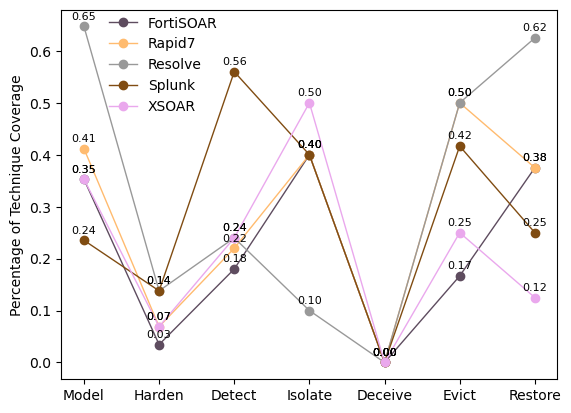

<Figure size 1500x1200 with 0 Axes>

In [127]:
# vendor_df
# filtered_only_upper_unsorted
# filtered_only_under
import random
from scipy.interpolate import make_interp_spline




barchart_tactics = ['Model','Harden','Detect','Isolate','Deceive','Evict','Restore']
vendor_list = []
vendor_excluded = ['Catalyst','IACD','OasisOpen', 'Chronicle','Tines','Demisto','LogicHub','Shuffle','ThreatConnect','CISA']
n = len(barchart_tactics)


df_reload = pd.read_csv('mapping.csv', header=None, names=['id','mapping'])

# df['mapping'] = df['mapping'].apply(ast.literal_eval)


merged_df = pd.merge(vendor_df, df_reload, on='id')
# print(merged_df.head())
index = np.arange(n)

for vendor in vendor_df['vendor']:
    if vendor not in vendor_list:
        if vendor not in vendor_excluded:
            vendor_list.append(vendor)
print(vendor_list)

# Function to generate random colors
def get_random_color(number):
    colors = ['#5e4c5f','#ffbb6f','#999999','#804c12','#eaa8ed']
    return colors[number]

# Keep track of used colors
used_colors = set()

bar_width = 0.35
# max coverage numeric value based on the under techniques
max_coverage = {'Model': 17, 'Harden': 29, 'Detect': 50, 'Isolate': 10, 'Deceive': 9, 'Evict': 12, 'Restore': 8}

coverage_kum = {'Model': [], 'Harden': [], 'Detect': [], 'Isolate': [], 'Deceive': [], 'Evict': [], 'Restore': []}
percentages_kum = []
color_start_index = 0

for vendor in vendor_list:
    color = get_random_color(color_start_index)
    color_start_index += 1
    df_vendor = merged_df[merged_df['vendor'] == vendor]
    # 1: List for the values
    percentage = []
    # 2: Iterate through the tactics and calculate coverage for the vendor
    for tactic in barchart_tactics:
        max_list = []
        matched_techniques = []
        data_value_number = 0
        for x in techniques_list[tactic]:
            max_list.append(x)
        for index, row in df_vendor.iterrows():
            mappings = row['mapping']
            mappings = ast.literal_eval(mappings)
            for map in mappings:
                if map in max_list:
                    if map not in matched_techniques:
                        matched_techniques.append(map)
                        data_value_number += 1
                    if map not in coverage_kum[tactic]:
                        coverage_kum[tactic].append(map)
  
        data_value_percentage = data_value_number / max_coverage[tactic]
        percentage.append(data_value_percentage)
   
    # 3: Plot the bar for the vendor
    #    --> plt.bar(index, values1, bar_width, label='Value Set 1')
    label_x = f'{vendor}'
    x_numeric = np.arange(len(barchart_tactics))
    x_smooth = np.linspace(x_numeric.min(), x_numeric.max(), 300)
    spl = make_interp_spline(x_numeric, percentage, k=2)  # k=3 for cubic spline
   # print(percentage)
    if vendor == "XSOAR":
        y_smooth = spl(x_smooth)
       # y_smooth = np.clip(y_smooth, 0,  0.5)
    else:
        y_smooth = spl(x_smooth)
        y_smooth = np.clip(y_smooth, 0,  0.88)
    # y_smooth = np.array(percentage)
    plt.plot(x_numeric, percentage, label=vendor, color=color, linewidth=1, marker='o')
    plt.xticks(x_numeric, barchart_tactics)
    plt.legend(loc='right',bbox_to_anchor=(0.34, 0.85), frameon=False)
   # plt.plot(x_smooth, y_smooth, label=vendor, color=color, linewidth=1, marker='o')
   # plt.xticks(x_numeric, barchart_tactics)
   # plt.legend(loc='right',bbox_to_anchor=(1.27, 0.15))
    for i, value in enumerate(percentage):
        plt.annotate(f'{value:.2f}', (x_numeric[i], percentage[i]), 
                     textcoords="offset points", xytext=(0,5), ha='center', fontsize=8, color='black')
print(coverage_kum)
# Plot the kumulative plot across the vendors
for tactic in coverage_kum:
    percentages_kum.append((len(coverage_kum[tactic])/max_coverage[tactic]))
    print(len(coverage_kum[tactic]))
    print(max_coverage[tactic])
x_numeric_kum = np.arange(len(barchart_tactics))
x_smooth_kum = np.linspace(x_numeric_kum.min(), x_numeric_kum.max(), 300)
#print(percentages_kum)
spl_kum = make_interp_spline(x_numeric_kum, percentages_kum, k=2)  # k=3 for cubic spline
y_smooth_kum = spl_kum(x_smooth_kum)
y_smooth_kum = np.clip(y_smooth_kum, 0,  1.1)

#plt.plot(x_smooth_kum, y_smooth_kum, label='Overall', color='red', linewidth=1, zorder=10)
#plt.scatter(0,0.88, color='red', label='Combined')
#plt.legend(loc='right',bbox_to_anchor=(1.28, 0.15))
#plt.text(0, 0.82, '88%', color='red', verticalalignment='bottom')
#plt.scatter(1,0.31, color='red', label='Combined')
#plt.text(1, 0.25, '31%', color='red', verticalalignment='bottom')
#plt.scatter(2,0.7, color='red', label='Combined')
#plt.text(2, 0.64, '70%', color='red', verticalalignment='bottom')
#plt.scatter(3,0.5, color='red', label='Combined')
#plt.text(3, 0.44, '50%', color='red', verticalalignment='bottom')
#plt.scatter(4,0.0, color='red', label='Combined')
#plt.text(4, 0.0, '0%', color='red', verticalalignment='bottom')
#plt.scatter(5,1.0, color='red', label='Combined')
#plt.text(5, 0.94, '100%', color='red', verticalalignment='bottom')
#plt.scatter(6,0.75, color='red', label='Combined')
#plt.text(5.88, 0.67, '69%', color='red', verticalalignment='bottom')
# Descriptions of the plot
#plt.xlabel('Mitre D3FEND Tactics')
plt.ylabel('Percentage of Technique Coverage')
#plt.title('The Coverage of Playbook Vendors over Mitre D3FEND Tactics')
plt.savefig("distribution_of_playbooks_lines.pdf", format='pdf')
plt.figure(figsize=(15,12))

plt.show()

## Barchart Diagram Tactics

   Tactics  amount
0    Model     145
1   Harden      32
2   Detect     449
3  Isolate     168
4  Deceive       0
5    Evict      91
6  Restore      76
961


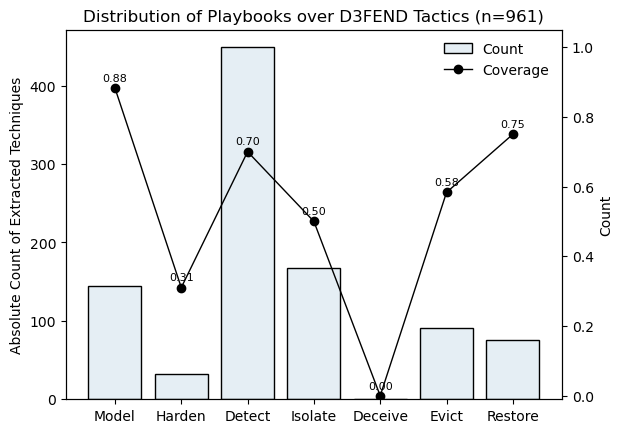

In [139]:
dataframe_playbook_count = {
    'Model':0, 'Harden':0, 'Detect':0, 'Isolate':0, 'Deceive':0, 'Evict':0, 'Restore':0  # Column with strings
}
colors = [(0.0, 0.3569, 0.5804, 0.1),(0.0, 0.3569, 0.5804, 0.1),(0.0, 0.3569, 0.5804, 0.1),(0.0, 0.3569, 0.5804, 0.1),(0.0, 0.3569, 0.5804, 0.1),
          (0.0, 0.3569, 0.5804, 0.1),(0.0, 0.3569, 0.5804, 0.1),(0.0, 0.3569, 0.5804, 0.1)]

sum = 0
for index, value in df_def.iterrows():
    tactics_i = value['tactics']
    for t in tactics_i:
        dataframe_playbook_count[t] +=1
        sum += 1
# Transform to DataFrame
df_tactics = pd.DataFrame.from_dict(dataframe_playbook_count, orient='index', columns=['amount']).reset_index()
df_tactics = df_tactics.rename(columns={'index': 'Tactics'})
print(df_tactics)
print(sum)

fig, ax1 = plt.subplots()
ax1.bar(df_tactics['Tactics'],df_tactics['amount'],label='Count', color=colors, edgecolor='black',)
#ax1.set_xlabel('D3FEND Tactics (no Tactic = None extracted)')
ax1.set_ylabel('Absolute Count of Extracted Techniques', color='black')
#ax1.set_title('Distribution of Playbooks over D3FEND Tactics (n=1217)')
#ax1.legend(loc='upper left', bbox_to_anchor=(0, 1.02))
# Create a second y-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Relative Coverage of the D3FEND Tactic', color='black')
ax2.set_ylim(-0.01, 1.05)  # Set the limits of the second y-axis
plt.xlabel('D3FEND Tactics (Others = None extracted)')
plt.ylabel('Count')
plt.title('Distribution of Playbooks over D3FEND Tactics (n=961)')
ax2.plot(x_numeric, percentages_kum, label='Coverage', color='black', linewidth=1, marker='o')
for i, value in enumerate(percentages_kum):
    ax2.annotate(f'{value:.2f}', (x_numeric[i], percentages_kum[i]), 
                 textcoords="offset points", xytext=(0,5), ha='center', fontsize=8, color='black')

# Combine legends from both ax1 and ax2
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(handles + handles2, labels + labels2,loc='upper right', bbox_to_anchor=(1, 1), frameon=False)
# 1396 Techniques insgesamt
# 1217 -909 = 308 ohne tactic
# 71 techniques
# d.h. gesamt techniques = 1088
# Detect % = 
plt.show()

In [80]:
focus_points = {'IdentifierReputationAnalysis':0,'IdentifierActivityAnalysis':0,'AssetVulnerabilityEnumeration':0,'OperationalRiskAssessment':0,
               'CredentialRotation':0,'SoftwareUpdate':0,'NetworkTrafficFiltering':0,'BroadcastDomainIsolation':0,'FileRemoval':0,'AccountLocking':0
               ,'RestoreNetworkAccess':0,'RestoreUserAccountAccess':0}

for index, value in df_def.iterrows():
    techniques = value['techniques_clean']
    for i in techniques:
        if i in focus_points:
            focus_points[i] +=1

print(focus_points)


{'IdentifierReputationAnalysis': 285, 'IdentifierActivityAnalysis': 61, 'AssetVulnerabilityEnumeration': 63, 'OperationalRiskAssessment': 33, 'CredentialRotation': 16, 'SoftwareUpdate': 5, 'NetworkTrafficFiltering': 114, 'BroadcastDomainIsolation': 47, 'FileRemoval': 33, 'AccountLocking': 32, 'RestoreNetworkAccess': 39, 'RestoreUserAccountAccess': 15}


## Statistics

In [5]:
# Arithmetische Mittel der Steps
steps_mean = df_def['steps'].mean(skipna=False)
steps_median = df_def['steps'].median(skipna=False)
print(f'Mean Playbook Steps: {steps_mean}')
print(f'Median Playbook Steps: {steps_median}')
print(" ")
tactics_mean = df_def['tactics_count'].mean(skipna=False)
tactics_median = df_def['tactics_count'].median(skipna=False)
tactics_variance = df_def['tactics_count'].var(skipna=False)
print(f'Mean Playbook Tactics: {tactics_mean}')
print(f'Median Playbook Tactics: {tactics_median}')
print(f'Variance Playbook Tactics: {tactics_variance}')
print(" ")
techniques_mean = df_def['techniques_count'].mean(skipna=False)
techniques_median = df_def['techniques_count'].median(skipna=False)
techniques_variance = df_def['techniques_count'].var(skipna=False)
print(f'Mean Playbook techniques: {techniques_mean}')
print(f'Median Playbook techniques: {techniques_median}')
print(f'Variance Playbook techniques: {techniques_variance}')
print(" ")
artifacts_mean = df_def['artifacts_count'].mean(skipna=False)
artifacts_median = df_def['artifacts_count'].median(skipna=False)
artifacts_ratio = df_def['ratio_a_s'].mean(skipna=False)
print(f'Mean artifacts: {artifacts_mean}')
print(f'Median artifacts: {artifacts_median}')
print(f'Ratio artifacts: {artifacts_ratio}')
print(" ")


filtered_df = df_def[df_def['techniques_count'] > 1]

ratio_t_s_mean = filtered_df['ratio_t_s'].mean(skipna=False)
ratio_t_s_med = filtered_df['ratio_t_s'].median(skipna=False)
print(f'Mean Techniques per Steps: {ratio_t_s_mean}')
print(f'Median Techniques per Steps: {ratio_t_s_med}')



Mean Playbook Steps: 8.239750445632799
Median Playbook Steps: 5.0
 
Mean Playbook Tactics: 0.85650623885918
Median Playbook Tactics: 1.0
Variance Playbook Tactics: 0.4994625374275896
 
Mean Playbook techniques: 2.2459893048128343
Median Playbook techniques: 2.0
Variance Playbook techniques: 3.562985684096037
 
Mean artifacts: 5.657754010695188
Median artifacts: 3.0
Ratio artifacts: 0.7113021505995558
 
Mean Techniques per Steps: 0.9325418683452071
Median Techniques per Steps: 0.5


### Zusammenhang Steps und Techniques

In [7]:
# Prozentzahlen der artifacts

gesamtzahl_artifacts = 6376
print(gesamtzahl_artifacts)
identifier_percentage = 406/gesamtzahl_artifacts
DI_b_perc = 329/gesamtzahl_artifacts
DI = 198/gesamtzahl_artifacts
NN = 108/gesamtzahl_artifacts
file_perc = 77/gesamtzahl_artifacts
ids = 70/gesamtzahl_artifacts
network = 48/gesamtzahl_artifacts
User = 35/gesamtzahl_artifacts
User_account = 23/gesamtzahl_artifacts
Metadata = 20/gesamtzahl_artifacts
print(f'Identifier: {identifier_percentage}')
print(f'D.I.Bearer: {DI_b_perc}')
print(f'D.I: {DI}')
print(f'Network Node: {NN}')
print(f'File: {file_perc}')
print(f'IDS: {ids}')
print(f'Network: {network}')
print(f'User: {User}')
print(f'User Account: {User_account}')
print(f'Metadata: {Metadata}')

6376
Identifier: 0.0636762860727729
D.I.Bearer: 0.05159974905897114
D.I: 0.031053952321204517
Network Node: 0.016938519447929738
File: 0.012076537013801757
IDS: 0.010978670012547051
Network: 0.0075282308657465494
User: 0.005489335006273526
User Account: 0.0036072772898368883
Metadata: 0.003136762860727729


In [9]:
calculations = {"Model":[],"Harden":[],"Detect":[],"Isolate":[],"Deceive":[],"Evict":[],"Restore":[]}

for index, value in df_def.iterrows():
    tactics = value['tactics']
    artifacts = value['artifacts']
    #print(artifacts)
    for t in tactics:
        for a in artifacts:
            calculations[t].append(a)

sum = 0
for i in calculations:
    print(i)
    sum += len(calculations[i])

print(sum)

Model
Harden
Detect
Isolate
Deceive
Evict
Restore
6376


In [11]:
calculations_artifact = {"Model":[],"Harden":[],"Detect":[],"Isolate":[],"Deceive":[],"Evict":[],"Restore":[]}
artifacts_perc = {"Identifier":{"Model":0,"Harden":0,"Detect":0,"Isolate":0,"Deceive":0,"Evict":0,"Restore":0},
                  "Digital Information Bearer":{"Model":0,"Harden":0,"Detect":0,"Isolate":0,"Deceive":0,"Evict":0,"Restore":0},
                  "Digital Information":{"Model":0,"Harden":0,"Detect":0,"Isolate":0,"Deceive":0,"Evict":0,"Restore":0},
             "Network Node":{"Model":0,"Harden":0,"Detect":0,"Isolate":0,"Deceive":0,"Evict":0,"Restore":0},"File":{"Model":0,"Harden":0,"Detect":0,"Isolate":0,"Deceive":0,"Evict":0,"Restore":0},
                  "Intrusion Detection System":{"Model":0,"Harden":0,"Detect":0,"Isolate":0,"Deceive":0,"Evict":0,"Restore":0},"Network":{"Model":0,"Harden":0,"Detect":0,"Isolate":0,"Deceive":0,"Evict":0,"Restore":0},
            "User":{"Model":0,"Harden":0,"Detect":0,"Isolate":0,"Deceive":0,"Evict":0,"Restore":0},"User Account":{"Model":0,"Harden":0,"Detect":0,"Isolate":0,"Deceive":0,"Evict":0,"Restore":0},"Metadata":{"Model":0,"Harden":0,"Detect":0,"Isolate":0,"Deceive":0,"Evict":0,"Restore":0}}

other_sum = 0
for index, value in df_def.iterrows():
    tactics = value['tactics']
    artifacts = value['artifacts']

    for a in artifacts:
        if a in artifacts_perc:
            for t in tactics:
                artifacts_perc[a][t] += 1
        else:
            other_sum += 1
print(artifacts_perc)

final_sum = 0
for ar in artifacts_perc:
    for tac in artifacts_perc[ar]:
        artifacts_perc[ar][tac]
        final_sum += artifacts_perc[ar][tac]
#print(final_sum)
#print(other_sum)
print(final_sum + other_sum)

#  Digital Information Bearer &  0.213 & 0.052 & 0.365 & 0.207 & 0.003 & 0.075 & 0.085 & XX.X\%

for art in artifacts_perc:
    artifacts_total = 6469
    result_latex = '\\textbf{x} & ' + art
    sum_artifact_row = 0 
    for tactic in artifacts_perc[art]:
        sum_artifact_row += artifacts_perc[art][tactic]
    percentage_artifact = round(sum_artifact_row/artifacts_total, 4)
   # print(percentage_artifact)
    for tactic in artifacts_perc[art]:
        number_absolut = artifacts_perc[art][tactic]
        result_latex = result_latex +  '& ' + str(round(number_absolut/artifacts_total, 4))
    
    result_latex += '&' + str(percentage_artifact) + "\\" + "\\"
    print(result_latex)

        

{'Identifier': {'Model': 98, 'Harden': 19, 'Detect': 1101, 'Isolate': 405, 'Deceive': 0, 'Evict': 94, 'Restore': 56}, 'Digital Information Bearer': {'Model': 158, 'Harden': 44, 'Detect': 268, 'Isolate': 187, 'Deceive': 0, 'Evict': 157, 'Restore': 96}, 'Digital Information': {'Model': 149, 'Harden': 20, 'Detect': 233, 'Isolate': 40, 'Deceive': 0, 'Evict': 29, 'Restore': 12}, 'Network Node': {'Model': 101, 'Harden': 32, 'Detect': 132, 'Isolate': 138, 'Deceive': 0, 'Evict': 46, 'Restore': 91}, 'File': {'Model': 30, 'Harden': 1, 'Detect': 150, 'Isolate': 64, 'Deceive': 0, 'Evict': 42, 'Restore': 11}, 'Intrusion Detection System': {'Model': 35, 'Harden': 11, 'Detect': 135, 'Isolate': 46, 'Deceive': 0, 'Evict': 22, 'Restore': 10}, 'Network': {'Model': 6, 'Harden': 2, 'Detect': 86, 'Isolate': 126, 'Deceive': 0, 'Evict': 11, 'Restore': 26}, 'User': {'Model': 17, 'Harden': 16, 'Detect': 75, 'Isolate': 18, 'Deceive': 0, 'Evict': 60, 'Restore': 27}, 'User Account': {'Model': 13, 'Harden': 18, 'De

In [13]:
# Ausspucken von den Evict Playbooks --> nachziehen der neuen Techniques

for id, row in df_def.iterrows():
    relevant_playbooks = row['playbook_id']
    tactic_evict = 'Evict'

    if tactic_evict in row['tactics']:
        print(relevant_playbooks)



p206
p214
p215
p224
p226
p227
p235
p247
p273
p274
p2
p41
p456
p457
p494
p495
p496
p497
p501
p502
p503
p504
p505
p535
p536
p537
p540
p541
p572
p578
p580
p583
p585
p592
p593
p615
p616
p617
p618
p627
p640
p641
p645
p646
p647
p653
p657
p664
p667
p685
p696
p710
p711
p746
p753
p755
p756
p757
p758
p765
p766
p806
p808
p812
p818
p821
p824
p833
p837
p852
p858
p862
p863
p865
p868
p872
p890
p895
p901
p905
p923
p1015
p1031
p1066
p1092
p1102
p1103
p1157
p1170
p1173
p1190


In [49]:
print(len(df_big))
print(f'Mean Artifacts in bin playbooks: {df_big['techniques_count'].mean(skipna= False)}')
print(f'Mean Artifacts in small playbooks: {df_small['techniques_count'].mean(skipna= False)}')
print(f'Mean Artifacts in small playbooks: {df_very_big['techniques_count'].median(skipna= False)}')
print(f'Mean Artifacts in all playbooks: {df_def['techniques_count'].median(skipna= False)}')


print(len(df_small))

240
Mean Artifacts in bin playbooks: 2.5083333333333333
Mean Artifacts in small playbooks: 2.0520965692503177
Mean Artifacts in small playbooks: 3.0
Mean Artifacts in all playbooks: 2.0
787


## Calculate LLM Accuracy

In [150]:
df_llm = pd.read_csv("LLm_mapping.csv", delimiter=';')
df_mapping = pd.read_csv('pb_mapping_iteration2.csv', sep=r'\s*;\s*', header=None)
#print(df.head())

df_mapping.columns = ['playbook','techniques']

for index, row in df_mapping.iterrows():
    
    df_mapping.at[index, 'techniques'] = row['techniques'][0:-1]
    df_mapping.at[index, 'playbook'] = row['playbook'][1:]
    # Assign the modified list back to the DataFrame
   # print(row['techniques'])

df_mapping['techniques'] = df_mapping['techniques'].apply(ast.literal_eval)

#df_llm.head(10)
df_mapping.head(10)

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_9168\2010115321.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_mapping = pd.read_csv('pb_mapping_iteration2.csv', sep=r'\s*;\s*', header=None)


,playbook,techniques
0,p101,[c:AdditionalTask]
1,p122,"[c:CTI_Input, IdentifierReputationAnalysis, Id..."
2,p123,"[c:CTI_Input, FileAnalysis, IdentifierReputati..."
3,p124,"[IdentifierReputationAnalysis, IdentifierAnaly..."
4,p125,"[c:CTI_Input, IdentifierReputationAnalysis, Id..."
5,p126,"[c:CTI_Input, IdentifierReputationAnalysis, Id..."
6,p127,"[c:CTI_Input, IdentifierReputationAnalysis, Id..."
7,p128,"[IdentifierAnalysis, IdentifierReputationAnaly..."
8,p129,"[IdentifierReputationAnalysis, IdentifierAnaly..."
9,p130,"[IdentifierReputationAnalysis, IdentifierAnaly..."


In [152]:
llm_extract = {}

for index, value in df_llm.iterrows():
    playbook = value['playbook']
    techniques = value['techniques']
    techniques = ast.literal_eval(techniques)
    techniques_simplified = []
    if len(techniques) >= 1:
        for i in techniques:
            if i != 'Categories':
                for num in i:
                  #  print(playbook)
                  #  print(i[num])
                   
                    if i[num]:
                        techniques_simplified.append(i[num])

    llm_extract[playbook] = techniques_simplified

print(llm_extract)

                            


{'p101': [], 'p122': ['FileHashReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis', 'FileAnalysis'], 'p123': ['FileHashReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis', 'FileAnalysis'], 'p124': ['IPReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis', 'DomainNameReputationAnalysis'], 'p125': ['IdentifierReputationAnalysis', 'IdentifierAnalysis', 'URLReputationAnalysis', 'DomainNameReputationAnalysis'], 'p126': ['IdentifierReputationAnalysis', 'IdentifierAnalysis', 'URLReputationAnalysis', 'DomainNameReputationAnalysis'], 'p127': ['DomainNameReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis', 'URLReputationAnalysis'], 'p128': ['SenderReputationAnalysis', 'SenderMTAReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis'], 'p129': ['FileHashReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis', 'FileAnalysis'], 'p130': ['FileHashReputationAnalysis', 'IdentifierR

In [154]:
results = {}
amount_llm = 0
amount_techniques = 0
for index, value in df_mapping.iterrows():
    string_vorbereitet = {'llm':0,'expert':0}
    playbook = value['playbook']
    techniques = value['techniques']
    amount_techniques += len(techniques)
    string_vorbereitet['expert'] = len(techniques)
    techniques_llm = []
    if playbook in llm_extract:
        techniques_llm = llm_extract[playbook]
        print(techniques_llm)

    else:
        techniques_llm = []

    for llm_tec in techniques_llm:
        amount_llm += 1 
        if llm_tec in techniques:
            string_vorbereitet['llm'] += 1

    results[playbook] = string_vorbereitet

#print(results)
print(amount_llm)         
print(amount_techniques)

[]
['FileHashReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis', 'FileAnalysis']
['FileHashReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis', 'FileAnalysis']
['IPReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis', 'DomainNameReputationAnalysis']
['IdentifierReputationAnalysis', 'IdentifierAnalysis', 'URLReputationAnalysis', 'DomainNameReputationAnalysis']
['IdentifierReputationAnalysis', 'IdentifierAnalysis', 'URLReputationAnalysis', 'DomainNameReputationAnalysis']
['DomainNameReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis', 'URLReputationAnalysis']
['SenderReputationAnalysis', 'SenderMTAReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis']
['FileHashReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis', 'FileAnalysis']
['FileHashReputationAnalysis', 'IdentifierReputationAnalysis', 'IdentifierAnalysis', 'FileAnalysis']
['FileHashReputationAnalysis', '

In [159]:
values = []
amount_correct = 0
amount_aexpected = 0
for pb in results:
    #print(results[pb]['llm']/results[pb]['expert'])
    values.append(results[pb]['llm']/results[pb]['expert'])
    amount_correct += results[pb]['llm']
    amount_aexpected += results[pb]['expert']
   # value = pb['llm']/pb['expert']
   # values.append(value)
#print(values)

mean = 0.0

sum = 0 
for x in values:
    sum += x

print(sum/len(values))
print(amount_correct)
print(amount_aexpected)
print(amount_aexpected - amount_correct)


print(f'LLM Accuracy:{761/2980}')

    

0.2269841912890039
761
2980
2219
LLM Accuracy:0.25536912751677854
